<a href="https://colab.research.google.com/github/lucastellano/online_retail_analytics/blob/master/Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Graficos
%matplotlib inline

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
os.listdir('/content')

['.config', 'drive', 'sample_data']

In [4]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv') or file.endswith('.xlsx'):
            print(os.path.join(root, file))

/content/drive/MyDrive/online_retail_II.csv
/content/drive/MyDrive/Boston.csv


In [5]:
df = pd.read_csv('/content/drive/MyDrive/online_retail_II.csv', encoding='latin-1')
print(f"Dataset cargado. Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Dataset cargado. Filas: 1,067,371 | Columnas: 8


In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [8]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [9]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

pd.DataFrame({'Nulos': nulos, 'Porcentaje': porcentaje})

,Nulos,Porcentaje
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [10]:
print(f"Fecha inicio: {df['InvoiceDate'].min()}")
print(f"Fecha fin:    {df['InvoiceDate'].max()}")

Fecha inicio: 2009-12-01 07:45:00
Fecha fin:    2011-12-09 12:50:00


In [11]:
# Copia del dataset
df_clean = df.copy()
print(f"Filas originales: {len(df_clean):,}")

Filas originales: 1,067,371


In [12]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print(df_clean['InvoiceDate'].dtype)

datetime64[ns]


In [13]:
df_clean['Invoice'].astype(str).str[:1].value_counts()

,count
Invoice,
5,939382
4,108489
C,19494
A,6


In [14]:
df_clean[df_clean['Invoice'].astype(str).str.startswith('C')].head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia


In [15]:
df_clean[df_clean['Invoice'].astype(str).str.startswith('A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [16]:
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('A')]
print(f"Filas después de limpiar: {len(df_clean):,}")

Filas después de limpiar: 1,047,871


In [17]:
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
print(f"Filas después de limpiar negativos: {len(df_clean):,}")

Filas después de limpiar negativos: 1,041,669


In [18]:
print(f"Filas con Customer ID nulo: {df_clean['Customer ID'].isnull().sum():,}")
print(f"Representan el {df_clean['Customer ID'].isnull().sum()/len(df_clean)*100:.1f}% del dataset limpio")

Filas con Customer ID nulo: 236,120
Representan el 22.7% del dataset limpio


In [19]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
print(f"Revenue total del dataset: £{df_clean['Revenue'].sum():,.2f}")

Revenue total del dataset: £20,961,532.51


In [20]:
print(f"Filas originales:        {len(df):,}")
print(f"Filas después de limpiar: {len(df_clean):,}")
print(f"Filas eliminadas:         {len(df) - len(df_clean):,}")
print(f"Porcentaje conservado:    {len(df_clean)/len(df)*100:.1f}%")

Filas originales:        1,067,371
Filas después de limpiar: 1,041,669
Filas eliminadas:         25,702
Porcentaje conservado:    97.6%


In [21]:
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [22]:
df_clean[['InvoiceDate', 'Year', 'Month', 'YearMonth']].head()

,InvoiceDate,Year,Month,YearMonth
0,2009-12-01 07:45:00,2009,12,2009-12
1,2009-12-01 07:45:00,2009,12,2009-12
2,2009-12-01 07:45:00,2009,12,2009-12
3,2009-12-01 07:45:00,2009,12,2009-12
4,2009-12-01 07:45:00,2009,12,2009-12


In [23]:
# Agrupacion por YearMonth y suma del revenue
revenue_mensual = df_clean.groupby('YearMonth')['Revenue'].sum().reset_index()
revenue_mensual['YearMonth'] = revenue_mensual['YearMonth'].astype(str)

print(revenue_mensual)

   YearMonth      Revenue
0    2009-12   825685.760
1    2010-01   652708.502
2    2010-02   553339.736
3    2010-03   833570.131
4    2010-04   681528.992
5    2010-05   659858.860
6    2010-06   752270.140
7    2010-07   650712.940
8    2010-08   697274.910
9    2010-09   924333.011
10   2010-10  1165483.910
11   2010-11  1470272.482
12   2010-12  1262598.790
13   2011-01   691364.560
14   2011-02   523631.890
15   2011-03   717639.360
16   2011-04   537808.621
17   2011-05   770536.020
18   2011-06   761739.900
19   2011-07   719221.191
20   2011-08   748076.320
21   2011-09  1058590.172
22   2011-10  1154979.300
23   2011-11  1509496.330
24   2011-12   638810.680


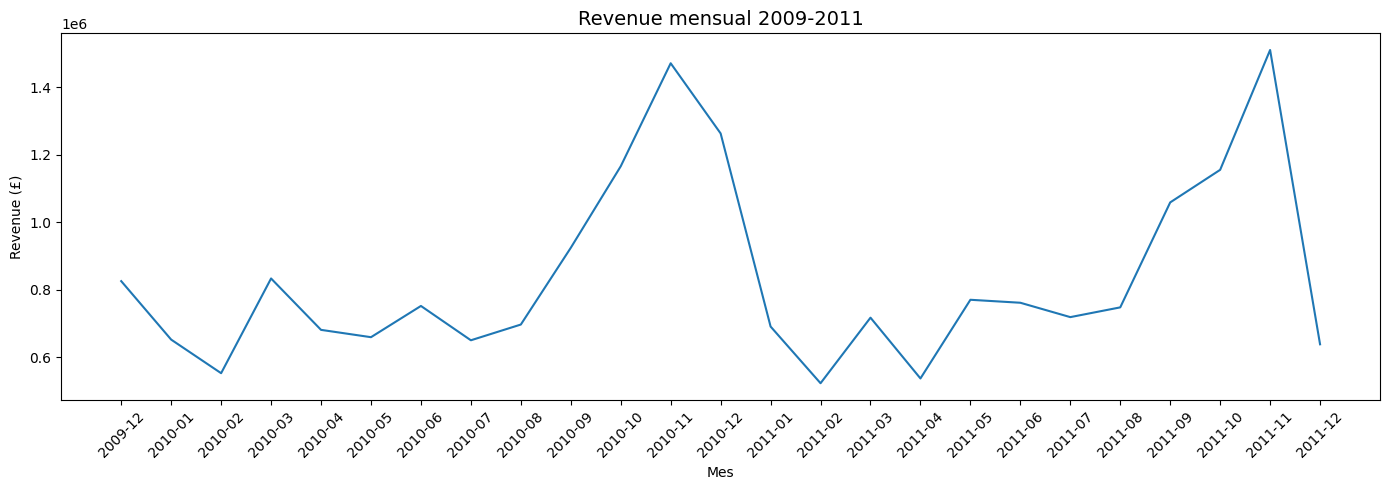

In [24]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=revenue_mensual, x='YearMonth', y='Revenue')
plt.title('Revenue mensual 2009-2011', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Top 10 productos por revenue
top_productos = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

print(top_productos)

                          Description    Revenue
0            REGENCY CAKESTAND 3 TIER  344563.25
1                              Manual  340731.33
2                      DOTCOM POSTAGE  322657.48
3  WHITE HANGING HEART T-LIGHT HOLDER  266923.55
4         PAPER CRAFT , LITTLE BIRDIE  168469.60
5             JUMBO BAG RED RETROSPOT  150935.56
6                       PARTY BUNTING  149187.05
7       ASSORTED COLOUR BIRD ORNAMENT  132187.92
8                             POSTAGE  127597.42
9     PAPER CHAIN KIT 50'S CHRISTMAS   123141.54


In [26]:
# Eliminar productos no reales
palabras_excluir = ['POSTAGE', 'Manual', 'DOTCOM']

mask = df_clean['Description'].str.contains('|'.join(palabras_excluir), case=False, na=False)
df_clean = df_clean[~mask]

# Recalcular top productos
top_productos = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_productos)

                           Description    Revenue
0             REGENCY CAKESTAND 3 TIER  344563.25
1   WHITE HANGING HEART T-LIGHT HOLDER  266923.55
2          PAPER CRAFT , LITTLE BIRDIE  168469.60
3              JUMBO BAG RED RETROSPOT  150935.56
4                        PARTY BUNTING  149187.05
5        ASSORTED COLOUR BIRD ORNAMENT  132187.92
6      PAPER CHAIN KIT 50'S CHRISTMAS   123141.54
7                        CHILLI LIGHTS   85489.91
8       MEDIUM CERAMIC TOP STORAGE JAR   81700.92
9  ROTATING SILVER ANGELS T-LIGHT HLDR   74448.92


/tmp/ipykernel_5966/742231516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_productos, x='Revenue', y='Description', palette='Blues_r')


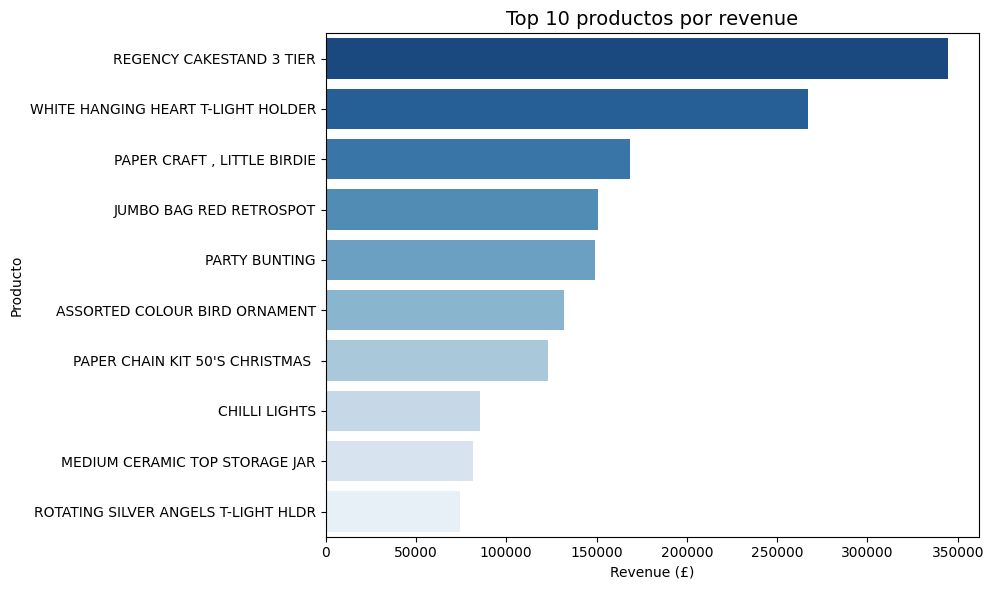

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_productos, x='Revenue', y='Description', palette='Blues_r')
plt.title('Top 10 productos por revenue', fontsize=14)
plt.xlabel('Revenue (£)')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

In [28]:
# Top 10 países por revenue (excluyendo UK porque domina todo)
top_paises = df_clean[df_clean['Country'] != 'United Kingdom'].groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

print(top_paises)

       Country     Revenue
0         EIRE  640572.000
1  Netherlands  549952.660
2      Germany  388959.991
3       France  317401.530
4    Australia  168484.660
5        Spain   98840.540
6  Switzerland   94270.290
7       Sweden   86353.040
8      Denmark   68560.190
9      Belgium   57322.770


/tmp/ipykernel_5966/2078049745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_paises, x='Revenue', y='Country', palette='Greens_r')


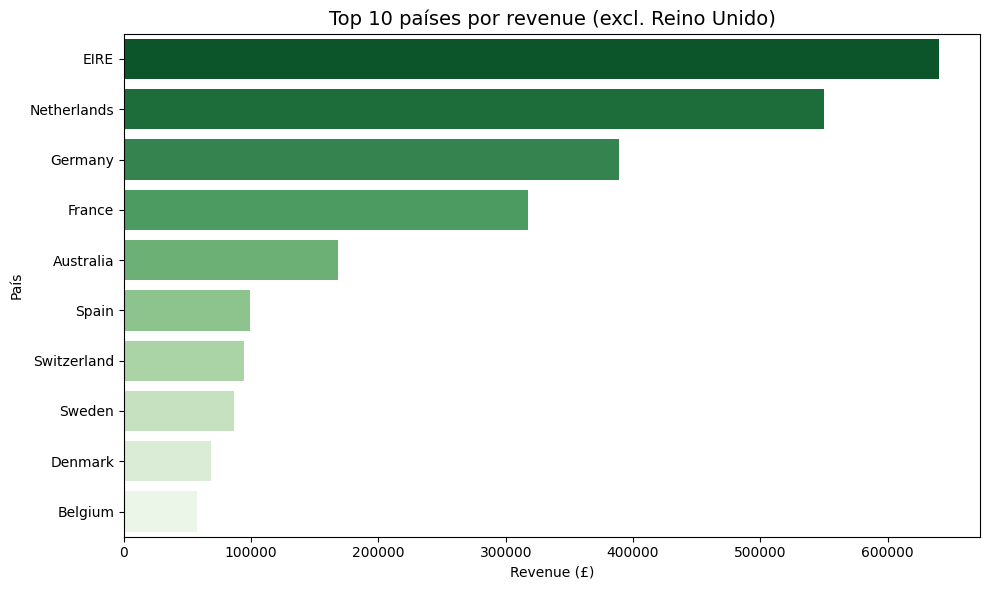

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_paises, x='Revenue', y='Country', palette='Greens_r')
plt.title('Top 10 países por revenue (excl. Reino Unido)', fontsize=14)
plt.xlabel('Revenue (£)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

In [30]:
# Filtramos solo filas con Customer ID conocido
df_rfm = df_clean[df_clean['Customer ID'].notna()].copy()
print(f"Filas con cliente identificado: {len(df_rfm):,}")
print(f"Clientes únicos: {df_rfm['Customer ID'].nunique():,}")

Filas con cliente identificado: 802,985
Clientes únicos: 5,862


In [31]:
fecha_referencia = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Fecha de referencia: {fecha_referencia}")

Fecha de referencia: 2011-12-10 12:50:00


In [32]:
rfm = df_rfm.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (fecha_referencia - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head(10))

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   1658.40
3      12349.0       19          3   3678.69
4      12350.0      310          1    294.40
5      12351.0      375          1    300.93
6      12352.0       36          9   1729.54
7      12353.0      204          2    406.76
8      12354.0      232          1   1079.40
9      12355.0      214          2    947.61


In [33]:
rfm['R_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary R_score F_score M_score
0      12346.0      326         12  77556.46       2       4       4
1      12347.0        2          8   5633.32       4       4       4
2      12348.0       75          5   1658.40       3       3       3
3      12349.0       19          3   3678.69       4       2       4
4      12350.0      310          1    294.40       2       1       1


In [34]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def segmentar(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP'
    elif r >= 3 and f >= 3:
        return 'Leal'
    elif r >= 3 and f <= 2:
        return 'Nuevo o prometedor'
    elif r <= 2 and f >= 3:
        return 'En riesgo'
    else:
        return 'Perdido'

rfm['Segmento'] = rfm.apply(segmentar, axis=1)

print(rfm['Segmento'].value_counts())

Segmento
Perdido               2043
Leal                  1381
En riesgo              888
Nuevo o prometedor     888
VIP                    662
Name: count, dtype: int64


/tmp/ipykernel_5966/2762760899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rfm['Segmento'].value_counts().values,


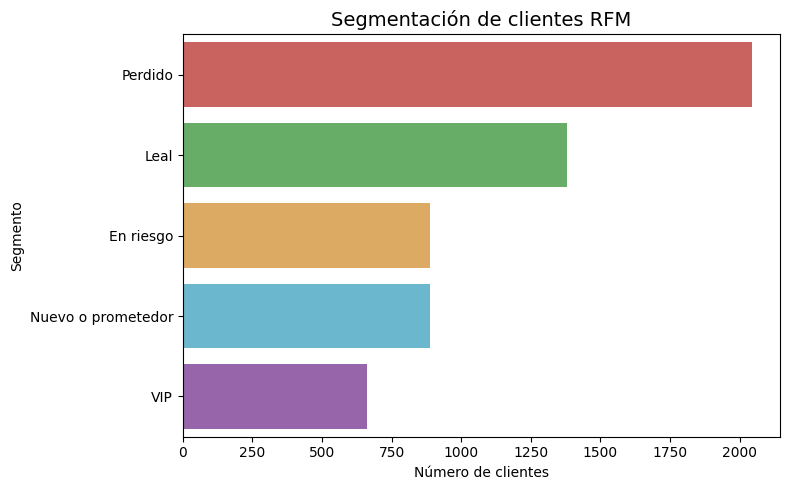

In [35]:
plt.figure(figsize=(8, 5))
colores = ['#d9534f', '#5cb85c', '#f0ad4e', '#5bc0de', '#9b59b6']
sns.barplot(x=rfm['Segmento'].value_counts().values,
            y=rfm['Segmento'].value_counts().index,
            palette=colores)
plt.title('Segmentación de clientes RFM', fontsize=14)
plt.xlabel('Número de clientes')
plt.ylabel('Segmento')
plt.tight_layout()
plt.show()